# Приоритизация гипотез и анализ A/B-теста в интернет-магазине

## Цели проекта

Проект состоит из двух частей и имеет следующие цели:

Приоритизация гипотез для запуска A/B-теста:
- Проверить гипотезы по фреймворкам ICE и RICE и определить лучшую гипотезу для тестирования.
- Провести A/B-тест:
- Проанализировать результаты теста.
- Принять решение о продолжении или завершении теста.


## Описание полученных данных

Данные для приоритизации гипотез для запуска A/B-теста:

- Файл hypothesis.csv:

Hypothesis — краткое описание гипотезы;

Reach — охват пользователей по 10-балльной шкале;

Impact — влияние на пользователей по 10-балльной шкале;

Confidence — уверенность в гипотезе по 10-балльной шкале;

Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.

Данные по результатам A/B-теста:

- Файл orders.csv:
transactionId — идентификатор заказа;
visitorId — идентификатор пользователя, совершившего заказ;
date — дата, когда был совершён заказ;
revenue — выручка заказа;
group — группа A/B-теста, в которую попал заказ.

- Файл visitors.csv:
date — дата;
group — группа A/B-теста;
visitors — количество пользователей в указанную дату в указанной группе A/B-теста.

# Загрузка данных и библиотек

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as st

# Загрузка файлов

In [3]:
hypothesis = pd.read_csv('***')
orders = pd.read_csv('***')
visitors = pd.read_csv('***')

In [4]:
# выведем информацию о датафрейме hypothesis
hypothesis.info()
print(hypothesis)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
                                          Hypothesis  Reach  Impact  \
0  Добавить два новых канала привлечения трафика,...      3      10   
1  Запустить собственную службу доставки, что сок...      2       5   
2  Добавить блоки рекомендаций товаров на сайт ин...      8       3   
3  Изменить структура категорий, что увеличит кон...      8       3   
4  Изменить цвет фона главной страницы, чтобы уве...      3       1   
5  Добавить страницу отзывов клиентов о магазине,...      3       2   
6  Показать на главной странице баннеры с актуаль...      5       3 

In [5]:
# выведем информацию о датафрейме orders
orders.info()
print(orders)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB
      transactionId   visitorId        date  revenue group
0        3667963787  3312258926  2019-08-15     1650     B
1        2804400009  3642806036  2019-08-15      730     B
2        2961555356  4069496402  2019-08-15      400     A
3        3797467345  1196621759  2019-08-15     9759     B
4        2282983706  2322279887  2019-08-15     2308     B
...             ...         ...         ...      ...   ...
1192     2662137336  3733762160  2019-08-14     6490     B
1193     2203539145   370388673  2019-08-14     3190     A
1194     18

In [6]:
# # выведем информацию о датафрейме visitors
visitors.info()
print(visitors)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
          date group  visitors
0   2019-08-01     A       719
1   2019-08-02     A       619
2   2019-08-03     A       507
3   2019-08-04     A       717
4   2019-08-05     A       756
..         ...   ...       ...
57  2019-08-27     B       720
58  2019-08-28     B       654
59  2019-08-29     B       531
60  2019-08-30     B       490
61  2019-08-31     B       718

[62 rows x 3 columns]


Вывод: Мы ознакомились с таблицами. Пропусков нет, однако тип данных в столбцах не везде корректный. Проверим данные на дубликаты и приведем наименования столбцов к единому стилю.

# Предобработка данных

In [7]:
# приведем наименования столбцов

hypothesis.columns = hypothesis.columns.str.lower()
hypothesis.columns

Index(['hypothesis', 'reach', 'impact', 'confidence', 'efforts'], dtype='object')

In [8]:
orders.columns = orders.columns.str.replace('Id', '_id')
hypothesis.columns
orders.columns

Index(['transaction_id', 'visitor_id', 'date', 'revenue', 'group'], dtype='object')

In [9]:
# меняем тип данных для столбцов с датами
visitors['date'] = pd.to_datetime(visitors['date'])
orders['date'] = pd.to_datetime(orders['date'])

In [10]:
# проверка на наличие дубликатов
display(visitors.duplicated().sum())
orders.duplicated().sum()

0

0

In [11]:
# проверим совпадают ли даты в файлах
display('Период заказов', orders['date'].min(), orders['date'].max(),
'Период пользователей', visitors['date'].min(), visitors['date'].max())

'Период заказов'

Timestamp('2019-08-01 00:00:00')

Timestamp('2019-08-31 00:00:00')

'Период пользователей'

Timestamp('2019-08-01 00:00:00')

Timestamp('2019-08-31 00:00:00')

In [12]:
# проверим количество заказов и пользователей по группам теста
display(orders.groupby('group').agg({'transaction_id': 'count'}))
display(visitors.groupby('group').agg({'visitors': 'sum'}))

,transaction_id
group,
A,557
B,640


,visitors
group,
A,18736
B,18916


In [13]:
# проверим корректность разбиения на группы 
len(orders.loc[orders['visitor_id'].isin(orders[orders['group']=='A']['visitor_id']) & 
               orders['visitor_id'].isin(orders[orders['group']=='B']['visitor_id']),'visitor_id'].unique())

58

Привели названия столбцов к общепринятому виду, поменяли тип данных, где это необходимо, а также проверили данные на дупликаты. Уточнили количество пользователей, которое входит в каждую из групп, а также проверили, есть ли пользователи, которые вошли в обе группе. Количество "задублировавшихся" пользоватей составило 58 человек, что может несколько исказить результаты.

# Приоритизация гипотез

Отдел маркетинга разработал список из девяти гипотез, каждая из которых оценена по шкале от 0 до 10. Воспользуемся одним из наиболее популярных методов приоритизации гипотез - ICE (англ. Impact, Confidence, Effort, что соответствует влиянию, уверенности и усилиям).

In [11]:
# выведем таблицу гипотез
hypothesis

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3
6,Показать на главной странице баннеры с актуаль...,5,3,8,3
7,Добавить форму подписки на все основные страни...,10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5


In [12]:
# добавим столбец к таблице с рейтингом ICE, округлим до 3 знаков после запятой, отсортируем и выведем результат
hypothesis['ice'] = round(hypothesis['impact'] * hypothesis['confidence'] / hypothesis['efforts'], 3)
hypothesis.sort_values(by='ice', ascending=False)

,hypothesis,reach,impact,confidence,efforts,ice
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5,16.200
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6,13.333
7,Добавить форму подписки на все основные страни...,10,7,8,5,11.200
6,Показать на главной странице баннеры с актуаль...,5,3,8,3,8.000
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3,7.000
1,"Запустить собственную службу доставки, что сок...",2,5,4,10,2.000
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3,1.333
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8,1.125
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1,1.000


Видим топ-5 лучших гипотез. Добавим к расчету параметр Reach(охват) и приоритезируем гипотезы по методу RICE.

# Приоритизация гипотез по RICE

In [13]:
hypothesis['rice'] = hypothesis['reach'] * hypothesis['impact'] * hypothesis['confidence'] / hypothesis['efforts']

hypothesis[['hypothesis', 'rice']].sort_values(by='rice', ascending=False)

,hypothesis,rice
7,Добавить форму подписки на все основные страни...,112.0
2,Добавить блоки рекомендаций товаров на сайт ин...,56.0
0,"Добавить два новых канала привлечения трафика,...",40.0
6,Показать на главной странице баннеры с актуаль...,40.0
8,"Запустить акцию, дающую скидку на товар в день...",16.2
3,"Изменить структура категорий, что увеличит кон...",9.0
1,"Запустить собственную службу доставки, что сок...",4.0
5,"Добавить страницу отзывов клиентов о магазине,...",4.0
4,"Изменить цвет фона главной страницы, чтобы уве...",3.0


Резульаты показывают, что наиболее перспективные гипотезы идут под номерами 7, 2, 0.

In [14]:
hypothesis[['hypothesis','ice', 'rice']].sort_values(by='rice', ascending=False).head(5)

,hypothesis,ice,rice
7,Добавить форму подписки на все основные страни...,11.200,112.0
2,Добавить блоки рекомендаций товаров на сайт ин...,7.000,56.0
0,"Добавить два новых канала привлечения трафика,...",13.333,40.0
6,Показать на главной странице баннеры с актуаль...,8.000,40.0
8,"Запустить акцию, дающую скидку на товар в день...",16.200,16.2


**Вывод**: наиболее подходящим фреймворком для приоритизации гипотез является фреймворк RICE, поскольку он учитывает охват гипотезы. Поэтому наиболее перспективными гипотезами будут следующие:

 - Добавление формы подписки на все основные страницы для сбора базы клиентов для email-рассылок.
 - Добавление блоков рекомендаций товаров на сайт интернет-магазина для повышения конверсии и среднего чека заказа.
 - Добавление двух новых каналов привлечения трафика, что позволит привлечь на 30% больше пользователей.

# Анализ A/B-теста

In [15]:
# создаем массив уникальных пар значений дат и групп теста
dates_grouped = orders[['date','group']].drop_duplicates()

# получаем агрегированные кумулятивные по дням данные о заказах 
orders_grouped = dates_grouped.apply(
    lambda x: orders[
        np.logical_and(
            orders['date'] <= x['date'], orders['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max',
            'group': 'max',
            'transaction_id': 'nunique',
            'visitor_id': 'nunique',
            'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])

orders_grouped.head(6)

,date,group,transaction_id,visitor_id,revenue
55,2019-08-01,A,24,20,148579
66,2019-08-01,B,21,20,101217
175,2019-08-02,A,44,38,242401
173,2019-08-02,B,45,43,266748
291,2019-08-03,A,68,62,354874
310,2019-08-03,B,61,59,380996


In [16]:
# получаем агрегированные кумулятивные по дням данные о посетителях интернет-магазина 

visitors_grouped = dates_grouped.apply(
    lambda x: visitors[
        np.logical_and(
            visitors['date'] <= x['date'], visitors['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max', 
            'group': 'max', 
            'visitors': 'sum'
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])

visitors_grouped.head(6)

,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845
310,2019-08-03,B,1803


In [17]:
# объединяем кумулятивные данные в одной таблице и присваиваем ее столбцам понятные названия

cumulative_data = orders_grouped.merge(
    visitors_grouped, 
    left_on=['date', 'group'], 
    right_on=['date', 'group']
)

cumulative_data.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

#Добавим расчетную колонку с конверсией.

cumulative_data['conversion'] = cumulative_data['orders'] / cumulative_data['visitors']
cumulative_data.head(6)

,date,group,orders,buyers,revenue,visitors,conversion
0,2019-08-01,A,24,20,148579,719,0.033380
1,2019-08-01,B,21,20,101217,713,0.029453
2,2019-08-02,A,44,38,242401,1338,0.032885
3,2019-08-02,B,45,43,266748,1294,0.034776
4,2019-08-03,A,68,62,354874,1845,0.036856
5,2019-08-03,B,61,59,380996,1803,0.033833


# Кумулятивная выручка по группам

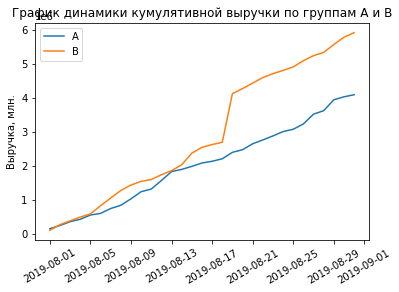

In [18]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_a = cumulative_data[cumulative_data['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_b = cumulative_data[cumulative_data['group']=='B'][['date','revenue', 'orders']]

plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue'], label='A')
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue'], label='B')
plt.title('График динамики кумулятивной выручки по группам А и В')
plt.ylabel("Выручка, млн.")
plt.xticks(rotation=30)
plt.legend()
plt.show()

Вывод: как видно по графику, кумулятивная выручка у группы В начинает расти с 5го дня. Однако, на данном этапе пока рано делать вывод, так как резкий скачок на 5й день может обуславливаться несколькими причинами: аномально резкий скачок в количестве заказов или же несколькими крупными заказами, которые так сильно заафектили кумулятивную выручки группы. 

# Cредний чек по группам

Построим график динамики кумулятивного среднего чека по группам.

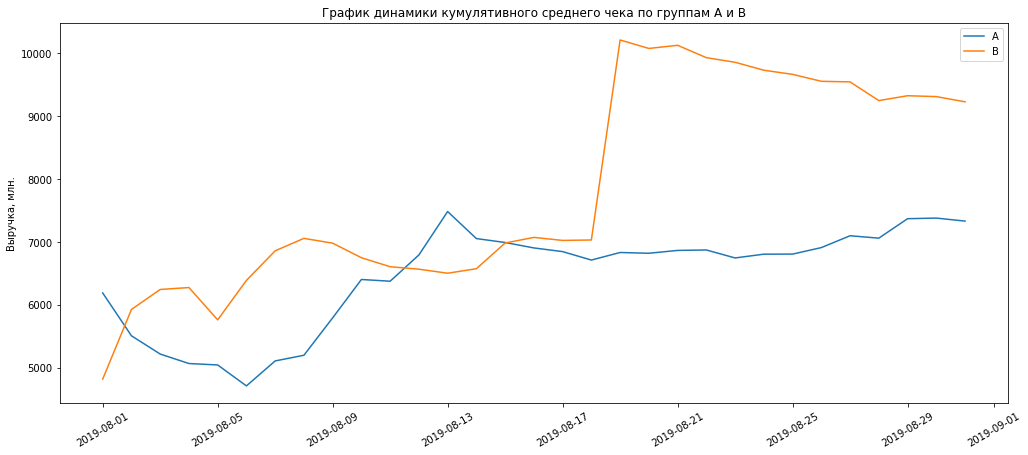

In [19]:
plt.figure(figsize=(17,7))
plt.plot(cumulative_revenue_a['date'], 
         cumulative_revenue_a['revenue'] / cumulative_revenue_a['orders'],
         label='A')

plt.plot(cumulative_revenue_b['date'], 
         cumulative_revenue_b['revenue'] / cumulative_revenue_b['orders'], 
         label='B')

plt.title('График динамики кумулятивного среднего чека по группам А и В')
plt.ylabel("Выручка, млн.")
plt.xticks(rotation=30)
plt.legend()
plt.show()

Вывод: здесь мы также видим резкий скачок у группы В на 5й день и длее последовавшее за этим снижение среднего чека, в то же время группа А показывает относительно стаблильный график без резкий колебаний, что подтверждает нашу догадку об аномально большом количестве заказов. 

# Относительноe изменениe кумулятивного среднего чека группы B к группе A

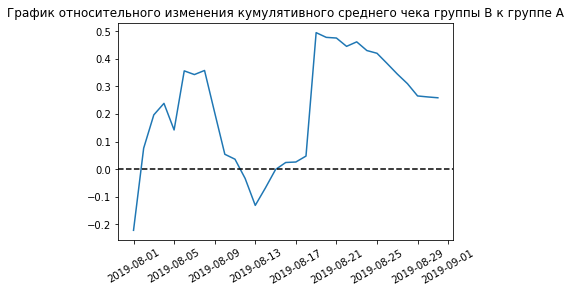

In [20]:
# собираем данные в одном датафрейме
cumulative_revenue_ab = cumulative_revenue_a.merge(
    cumulative_revenue_b, 
    left_on='date', 
    right_on='date', 
    how='left', 
    suffixes=['_a', '_b']
)

# cтроим отношение средних чеков
plt.plot(cumulative_revenue_ab['date'], 
         (
             cumulative_revenue_ab['revenue_b']/cumulative_revenue_ab['orders_b']
         )/
         (
             cumulative_revenue_ab['revenue_a']/cumulative_revenue_ab['orders_a']
         )-1
        )

# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--')
plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A')
plt.xticks(rotation=30)
plt.show()

Вывод: График относительного изменения кумулятивного среднего чека группы В к группе А повторяет динамику графика кумулятивного среднего чека.

# График кумулятивного среднего количества заказов на посетителя по группам.

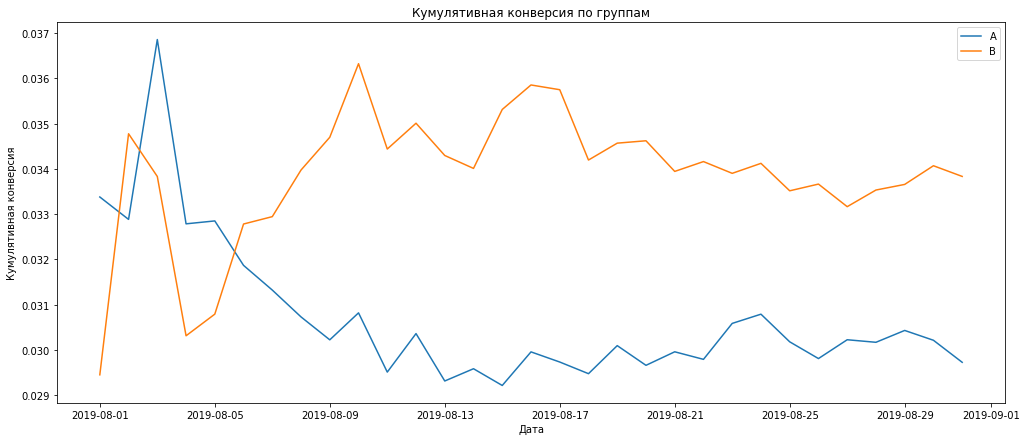

In [21]:
# к общей кумулятивной таблице добавим столбец с конверсией 
# и создадим две отдельные таблицы с разделением по группам
cumulative_data['conversion'] = cumulative_data['orders'] / cumulative_data['visitors']

cumulative_data_a = cumulative_data[cumulative_data['group']=='A']
cumulative_data_b = cumulative_data[cumulative_data['group']=='B']

cumulative_data.head()

# строим график кумулятивной конверсии по группам
plt.figure(figsize=(17,7))
plt.plot(cumulative_data_a['date'], cumulative_data_a['conversion'], label='A');
plt.plot(cumulative_data_b['date'], cumulative_data_b['conversion'], label='B');
plt.title('Кумулятивная конверсия по группам')
plt.xlabel("Дата")
plt.ylabel("Кумулятивная конверсия")
plt.legend()
plt.show()


Вывод: на графике видим, что изначально количество заказов на посетилей группы А была несколько выше количества заказов группы В, однако начиная с с 5го дня ситуация меняется: показатели группы В преобладают над показателями группы А. В дальнейшем графика стабилизируются. 

# График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A.

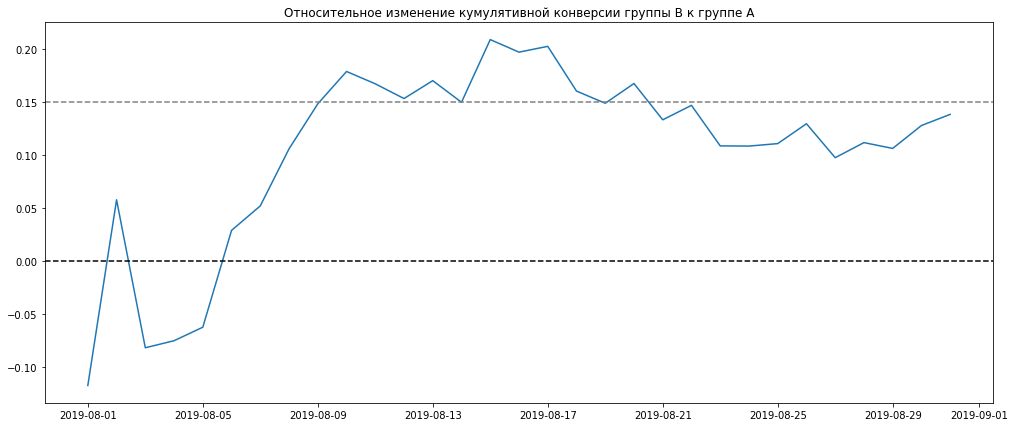

In [22]:
# создадим объединенную таблицу кумулятивной конверсии с сохранение столбцов conversion 
merged_cumulative_conversions = (cumulative_data_a[['date','conversion']]
                                     .merge(cumulative_data_b[['date','conversion']],
                                            left_on='date', right_on='date',
                                            how='left',
                                            suffixes=['_a', '_b'])
                                )
merged_cumulative_conversions.head()

# строим график отношения кумулятивной конверсии группы B к группе А 
plt.figure(figsize=(17,7))
plt.plot(merged_cumulative_conversions['date'],
         merged_cumulative_conversions['conversion_b'] / merged_cumulative_conversions['conversion_a']-1)
plt.title('Относительное изменение кумулятивной конверсии группы B к группе A')
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.15, color='grey', linestyle='--')
plt.show()

Вывод: график относительного изменения кумулятивной конверсии группы В к группе А еще раз подтверждает рост относительно показателей группы А начиная с 5го дня. с 9го дня конверсия группы В достигает 15% и колеблется в диапазоне 15-20% вплоть до 20го мая. 

# Точечный график количества заказов по пользователям.

count    1031.000000
mean        1.161009
std         0.724919
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        11.000000
Name: orders, dtype: float64

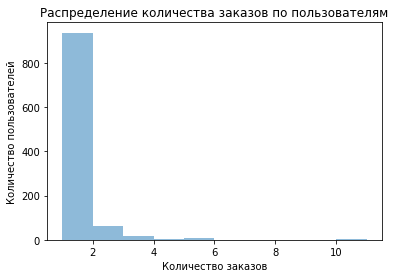

In [23]:
orders_by_users = (
    orders.groupby('visitor_id', as_index=False)
    .agg({'transaction_id': 'nunique'})
)
orders_by_users.columns =  ['visitor_id', 'orders']
display(orders_by_users['orders'].describe())

# строим гистограмму
plt.hist(orders_by_users['orders'], alpha=0.5) 
plt.title('Распределение количества заказов по пользователям')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')
plt.show()

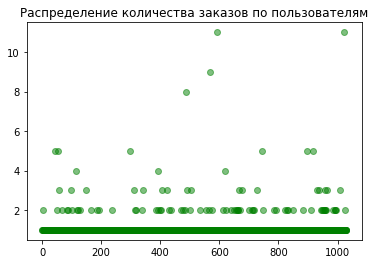

In [24]:
x_values = pd.Series(range(0,len(orders_by_users)))

# строим точечную диаграмму
plt.scatter(x_values, orders_by_users['orders'], color='green', alpha=0.5)
plt.title('Распределение количества заказов по пользователям')
plt.show()

Вывод: Большинство пользователей делают заказ только один раз, но при этом есть доля пользователей, которая совершает по 2 заказа. Доля тех, кто совершил от 3 до 11 заказов за месяц, достаточно низкая. Для того, чтобы убедиться в этом, посчитаем 95-й и 99-й перцентили количества заказов на пользователя.

# 95-й и 99-й перцентили количества заказов на пользователя.

In [25]:
np.percentile(orders_by_users['orders'], [95, 99])

array([2., 4.])

Вывод: Не более 5% пользователей совершали больше 2-х покупок в течение тестирования. И только 1% - четыре и более.
В качестве границы для определения аномальных пользователей выберем пользователей, которые сделали более 4х заказов. 

# Cтоимость заказов пользователей

count    1.197000e+03
mean     8.348006e+03
std      3.919113e+04
min      5.000000e+01
25%      1.220000e+03
50%      2.978000e+03
75%      8.290000e+03
max      1.294500e+06
Name: revenue, dtype: float64

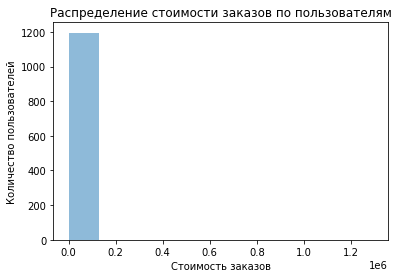

In [26]:
display(orders['revenue'].describe())

# строим гистограмму
plt.hist(orders['revenue'], alpha=0.5) 
plt.title('Распределение стоимости заказов по пользователям')
plt.xlabel('Стоимость заказов')
plt.ylabel('Количество пользователей')
plt.show()

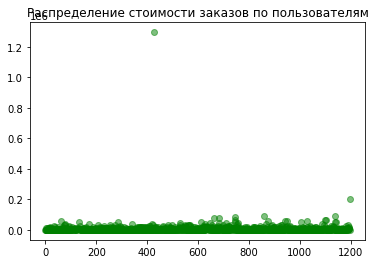

In [27]:
x_values = pd.Series(range(0,len(orders['revenue'])))

# строим точечную диаграмму
plt.scatter(x_values, orders['revenue'], color='green', alpha=0.5)
plt.title('Распределение стоимости заказов по пользователям')
plt.show()


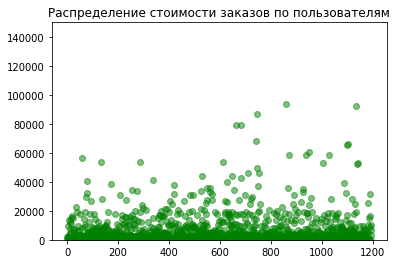

In [28]:
# строим точечную диаграмму
plt.ylim(0, 150000)
plt.scatter(x_values, orders['revenue'], color='green', alpha=0.5)
plt.title('Распределение стоимости заказов по пользователям')
plt.show()

Мы видим, что основная масса заказов не привышает 20000.

Посчитаем 95-й и 99-й перцентили стоимости заказов на пользователя и выберим границу для определения аномалий.

In [29]:
np.percentile(orders['revenue'], [95, 99])

array([28000. , 58233.2])

Вывод: как мы видим, стоимость 1% заказов превышает 58233,  Исходя из этого в качестве границе для определения аномальных заказов выберем 58233. 

# Изучение статистических значимостей

Изучим статистические значимости между группами по «сырым» данным — без удаления аномальных пользователей.

Введем основную и альтернативные гипотезы:

Н0 - различий в конверсии между группами нет
Н1 - различия в конверсии между группами есть
 

Уровень значимости: 0.05

# Подготовка сырых данных

In [30]:
# создадим таблицы ежедневного количества пользователей по группам
# и таблицы с кумулятивным количеством пользователей к дате по группам
visitors_daily_A = visitors[visitors['group']=='A'][['date', 'visitors']]
visitors_daily_A.columns = ['date', 'visitors_per_date_A']

visitors_daily_B = visitors[visitors['group']=='B'][['date', 'visitors']]
visitors_daily_B.columns = ['date', 'visitors_per_date_B']


visitors_cummulative_A = visitors_daily_A.apply(lambda x: 
                            visitors_daily_A[visitors_daily_A['date'] <= x['date']].agg({
                                'date' : 'max', 'visitors_per_date_A' : 'sum'}), axis=1)
visitors_cummulative_A.columns = ['date', 'visitors_cummulative_A']

visitors_cummulative_B = visitors_daily_B.apply(lambda x: 
                            visitors_daily_B[visitors_daily_B['date'] <= x['date']].agg({
                                'date' : 'max', 'visitors_per_date_B' : 'sum'}), axis=1)
visitors_cummulative_B.columns = ['date', 'visitors_cummulative_B']

In [31]:
# создадим таблицы с количеством заказов и размером выручки по группам
# и затем создадим таблицы с кумулятивным количеством заказов и выручки
orders_daily_A = orders[orders['group']=='A'][['date', 'transaction_id','visitor_id', 
                                               'revenue']].groupby(
    'date', as_index=False).agg({'transaction_id' : pd.Series.nunique, 'revenue' : 'sum'})
orders_daily_A.columns = ['date', 'orders_per_date_A', 'revenue_per_date_A']

orders_daily_B = orders[orders['group']=='B'][['date', 'transaction_id','visitor_id', 
                                               'revenue']].groupby(
    'date', as_index=False).agg({'transaction_id' : pd.Series.nunique, 'revenue' : 'sum'})
orders_daily_B.columns = ['date', 'orders_per_date_B', 'revenue_per_date_B']


orders_cummulative_A = orders_daily_A.apply(
    lambda x: orders_daily_A[orders_daily_A['date'] <= x['date']].agg({
                'date' : 'max',
                'orders_per_date_A' : 'sum',
                'revenue_per_date_A' : 'sum'}), axis=1).sort_values(by=['date'])
orders_cummulative_A.columns = ['date', 'orders_сummulative_A', 'revenue_сummulative_A']

orders_cummulative_B = orders_daily_B.apply(
    lambda x: orders_daily_B[orders_daily_B['date'] <= x['date']].agg({
                'date' : 'max',
                'orders_per_date_B' : 'sum',
                'revenue_per_date_B' : 'sum'}), axis=1).sort_values(by=['date'])
orders_cummulative_B.columns = ['date', 'orders_сummulative_B', 'revenue_сummulative_B']

In [32]:
# объединим все созданные таблицы в одну по дате
data = (visitors_daily_A
        .merge(visitors_daily_B, left_on='date', right_on='date', how='left')
        .merge(visitors_cummulative_A, left_on='date', right_on='date', how='left')
        .merge(visitors_cummulative_B, left_on='date', right_on='date', how='left')
        .merge(orders_daily_A, left_on='date', right_on='date', how='left')
        .merge(orders_daily_B, left_on='date', right_on='date', how='left')
        .merge(orders_cummulative_A, left_on='date', right_on='date', how='left')
        .merge(orders_cummulative_B, left_on='date', right_on='date', how='left')
       )

In [33]:
# создадим таблицы с количеством заказов по пользователям для каждой группы
orders_by_visitors_A = orders[orders['group']=='A'].groupby(
    'visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})

orders_by_visitors_A.columns = ['visitor_id', 'orders']

orders_by_visitors_B = orders[orders['group']=='B'].groupby(
    'visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})

orders_by_visitors_B.columns = ['visitor_id', 'orders']

sample_A = pd.concat([orders_by_visitors_A['orders'],
                     pd.Series(0, index=np.arange(
                         data['visitors_per_date_A'].sum() -
                         len(orders_by_visitors_A['orders'])),
                               name='orders')],axis=0)

sample_B = pd.concat([orders_by_visitors_B['orders'],
                     pd.Series(0, index=np.arange(
                         data['visitors_per_date_B'].sum() -
                         len(orders_by_visitors_B['orders'])), 
                               name='orders')],axis=0)

In [34]:
# посчитаем критерий Манна-Уитни к конверсии
# и относительный прирост конверсии группы B

print('Значение p-value для конверсий: {:.3f}'.format(st.mannwhitneyu(sample_A, sample_B)[1]))

if st.mannwhitneyu(sample_A, sample_B)[1] < 0.05:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")
    
print('Относительный прирост конверсии группы B: {:.2%}'.format((sample_B.mean()/sample_A.mean()) - 1))

Значение p-value для конверсий: 0.017
Отвергаем нулевую гипотезу
Относительный прирост конверсии группы B: 13.81%


По сырым данным различия в конверсии между группами есть. P-value = 0.017, что меньше 0.05. Исходя из этого, нулевую гипотезу о том, что статистически значимых различий в конверсии между группами нет, отвергаем. Относительный прирост конверсии группы B равен 13.81%.

# Cтатистическая значимость различий в среднем чеке заказа между группами, «сырые» данные

Изучим статистические значимости различий в среднем чеке заказа между группами по «сырым» данным — без удаления аномальных пользователей.

Введем основную и альтернативные гипотезы:

- Н0 - различий в конверсии между группами нет

- Н1 - различия в конверсии между группами есть

Уровень значимости: 0.05

In [35]:
# посчитаем критерий Манна-Уитни к среднему чеку
# и относительный прирост среднего чека группы B

pvalue_mean_check = st.mannwhitneyu(orders.query('group == "A"')['revenue'], orders.query('group == "B"')['revenue'])[1]

print('Значение p-value для среднего чека: {:.3f}'.format(pvalue_mean_check))

if pvalue_mean_check < 0.05:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

print('Относительный прирост среднего чека группы B: {:.2%}'
        .format((orders.query('group == "B"')['revenue'].mean() / orders.query('group == "A"')['revenue'].mean()) - 1))



Значение p-value для среднего чека: 0.729
Не получилось отвергнуть нулевую гипотезу
Относительный прирост среднего чека группы B: 25.87%


По сырым данным p-value составил 0.729, что превышает уровень значимости 0.05. Это означает, что причин отвергать нулевую гипотезу и считать, что в среднем чеке есть различия, нет. Однако, стоит отметить, что средний чек группы B значительно выше среднего чека группы A на 25.87%. Тем не менее, это различие не является статистически значимым.

# Cтатистическая значимость различий в конверсии между группами, «очищенные» данные

Изучим статистические значимости различий в конверсии между группами по «очищенным» данным — без удаления аномальных пользователей.

Введем основную и альтернативные гипотезы:

- Н0 - различий в конверсии между группами нет

- Н1 - различия в конверсии между группами есть

Уровень значимости: 0.05

In [36]:
# создадим таблицы с аномальными пользователей и выведем их количество и долю
visitors_many_orders = pd.concat([orders_by_visitors_A.query('orders > 5')['visitor_id'], 
                                  orders_by_visitors_B.query('orders > 5')['visitor_id']], axis = 0)
visitors_expensive_orders = orders.query('revenue > 58233')['visitor_id']


abnormal_visitors = (pd.concat([visitors_many_orders, visitors_expensive_orders], axis = 0)
                     .drop_duplicates()
                     .sort_values()
                    )

print('Количество аномальных пользователей:',len(abnormal_visitors))
print('Доля аномальных пользователей {:.2%}'.format(len(abnormal_visitors) / len(orders['visitor_id'].unique())))

Количество аномальных пользователей: 13
Доля аномальных пользователей 1.26%


Вывод: Всего нашли 13 "аномальных пользователей", их доля составила 1.26%, что позволяет не учитывать их при расчете очистке данных.  

In [37]:
# создадим таблицы с количеством заказов по пользователям для каждой группы без аномальных пользователей
sample_A_filt = pd.concat(
                    [orders_by_visitors_A[np.logical_not(orders_by_visitors_A['visitor_id']
                            .isin(abnormal_visitors))]['orders'],
                            pd.Series(0, index=np.arange(data['visitors_per_date_A'].sum() - 
                            len(orders_by_visitors_A['orders'])),
                            name='orders')],
                            axis=0
                         )

sample_B_filt = pd.concat(
                    [orders_by_visitors_B[np.logical_not(orders_by_visitors_B['visitor_id']
                           .isin(abnormal_visitors))]['orders'],
                           pd.Series(0, index=np.arange(data['visitors_per_date_B'].sum() - 
                           len(orders_by_visitors_B['orders'])),
                           name='orders')],
                           axis=0
                         )

Теперь проверим наши гипотеза на очищенных данных. 

In [38]:
# посчитаем критерий Манна-Уитни к конверсии для "очищенных" данных
# и относительный прирост конверсии группы B
print('Значение p-value для конверсий: {:.3f}'.format(st.mannwhitneyu(sample_A_filt, sample_B_filt)[1]))

if st.mannwhitneyu(sample_A_filt, sample_B_filt)[1] < 0.05:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

print('Относительный прирост конверсии группы B: {:.2%}'.format((sample_B_filt.mean() / sample_A_filt.mean()) - 1))

Значение p-value для конверсий: 0.015
Отвергаем нулевую гипотезу
Относительный прирост конверсии группы B: 14.87%


Вывод: на очищенных данных разница в конверсии между группами есть, а относительный прирост конверсии группы В отнистельно группы А составил 14.87%.

# Cтатистическая значимость различий в среднем чеке заказа между группами, «очищенные» данные

Изучим статистические значимости различий в среднем чеке заказа между группами по «очищенным» данным — без удаления аномальных пользователей.

Введем основную и альтернативные гипотезы:

- Н0 - различий в конверсии между группами нет

- Н1 - различия в конверсии между группами есть

Уровень значимости: 0.05

In [39]:
# посчитаем критерий Манна-Уитни к среднему чеку для очищенных данных 
# и относительный прирост среднего чека группы В

filtered_pvalue_mean_check = st.mannwhitneyu(
    orders[np.logical_and(orders['group'] == "A", np.logical_not(orders['visitor_id'].isin(abnormal_visitors)))]['revenue'],
    orders[np.logical_and(orders['group'] == "B", np.logical_not(orders['visitor_id'].isin(abnormal_visitors)))]['revenue'])[1]

print('Значение p-value для среднего чека: {:.3f}'.format(filtered_pvalue_mean_check))


if filtered_pvalue_mean_check < 0.05:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

    
print('Относительный прирост среднего чека группы B: {:.2%}'.format(
    (orders[np.logical_and(orders['group']=='B', np.logical_not(orders['visitor_id'].isin(abnormal_visitors)))]['revenue'].mean()/
     orders[np.logical_and(orders['group']=='A', np.logical_not(orders['visitor_id'].isin(abnormal_visitors)))]['revenue']
     .mean()) - 1))


Значение p-value для среднего чека: 0.679
Не получилось отвергнуть нулевую гипотезу
Относительный прирост среднего чека группы B: -0.11%


Вывод

Cтатистически значимых различий в среднем чеке нет между группами, значит мы не можем отвергнуть нулевую гипотезу. Однако относительный прирост среднего чека группы В на очищенных данных изменился до -0.11%. Но это может быть вызвано тем, что количество заказов у группы B больше, чем у группы A, за счет чего средний чек становится меньше.

# Итоговый вывод

Перед проведением A/B-теста мы выбирали наиболее перспективную гипотезу из списка из 8, используя фреймворки ICE и RICE. Учитывая необходимость охвата максимального числа пользователей, мы предпочли RICE, который учитывает этот фактор. Наиболее перспективными оказались следующие гипотезы:
 - "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",
 - "Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",
 - "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей".
 
Выполнив предоработку и проверку данных, обнаружили, что 58 пользователей попали в обе группы, что могли несколько исказить процесс анализа и проверки гипотез. 

В части анализа А/В теста мы выяснили, что 

 - Конверсия группы B выше, чем у группы А, начиная с 5 дня, что привело к большему числу заказов и немного увеличило средний чек.
 - С середины месяца динамика конверсий обеих групп стабилизировалась и группа В показывает более высокий уровень конверсии, чем группа А.
 - Кумулятивная выручка у группы В выше, чем у группы А.
 - В группе В оказались пользователи, которые совершили крупные заказы, что подняло средний чек группы. Учитывая то, что в группе А такого поведения не наблюдалось - это может быть новой точкой роста и требует изучения.

Проведя статистический анализ результатов теста мы пришли к выводам:

 - Статистические значимые различия в конверсии между группами теста есть, как на сырых, так и на очищенных данных.
 - Статистических значимых различий в среднем чеке между группами теста нет, как на сырых, так и на очищенных данных.
Исходя из этого, делаем вывод, что группа В показала наилучшие результаты.

Также, мы можем отметить следующие особенности, которые могут помочь маркетологам:

- Основная доля пользователей совершает только один заказ в месяц, 5% пользователей совершает более двух заказов и 1% более 4 заказов.
- Основная доля пользователей совершает заказы до 28 000. 
- Только 5% пользователей совершают заказы более 28тыс 
- 1% совершают заказы на 58000+.